# **STAGE 2 - ETL**

## Objectives

* In this Jupyter Notebook, I want to load and inspect the anonymised raw dataset: `animal_charity_donation_records_anonymised.csv`
* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/wildlife-charity-giving-analytics/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/wildlife-charity-giving-analytics'

---

# Import Libraries and Packages

In order to read `animal_charity_donation_records_anonymised.csv` and create visualisations for exploratory analysis, I need to install the following libraries and packages:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

* *Troubleshooting Issues:* The first time I imported the Libraries and Packages, I erroneously imported `numpy as pd` instead of `numpy as np`. This has been updated in my repository. 

---

# Section 1 - Extraction

* In this first section, **Extraction**, I am looking to gain a baseline understanding of what my data looks like before I move on to cleaning and transforming.
* We were taught a really important acronym for the initial part of this process - **DISH** - where the letters stand for:

| **Letter** | **Function / Attribute**|
|----------|-----------|
|**D**| `.describe()`|
|**I**| `.info()`|
|**S**| `.shape` |
|**H**| `.head()` |

* Additionally to these functions / attributes, I will also look to add the following extraction steps:

| **Function / Attribute** |
|-----------|
| `.dtypes` |
| `.isnull().sum()`|

In [19]:
# Load the anonymised raw dataset
df_anonymised = pd.read_csv("datasets/anonymised-raw-data/animal_charity_donation_records_anonymised.csv")

# Display the first few rows of the dataset to check the data has loaded correctly
df_anonymised.head()

,anonymised_donor_id,age_group,gender,country,donation_type,donation_amount,donation_date,payment_method,newsletter_opt_in,referral_channel,sector,campaign
0,f887acec7d236a724e0cd0df5112c6a7641e2b6867aeb9...,50-65,Female,UK,Monthly,115.31,2024-10-24,Paypal,False,Website,Real Estate,Rescue Orphaned Gorillas
1,db1fd2f0b9dd06646c1713945fda992a7250b512cce720...,50-65,Female,USA,One-time,8.60,2024-06-21,Bank Transfer,False,Online advertising,Logistics,Rescue Orphaned Gorillas
2,2723050e7f8594d0642ce8eb7396f17628b99c2ac9a038...,50-65,Female,USA,One-time,40.07,2024-08-21,Bank Transfer,False,Online advertising,Media & Communication,Marine Mammal Defense Mission
3,250222dcc99547fe972a1ee5702b4ab7d96246329228cb...,18-29,Male,USA,One-time,45.17,2023-10-09,Bank Transfer,False,Online advertising,Government,Wildlife Rescue Van Drive
4,e5b077c046e41a98c2c7689f06f41bc7a43ca2667a1968...,30-49,Female,UK,One-time,85.84,2024-09-01,Bank Transfer,True,Newsletter,Science & Research,Habitat for Hope


* From running this code cell, I can see that the data loaded is what I was expecting, having transformed our raw dataset with PII into this anonymised version.

In [20]:
# Display the shape of the dataset we are working with
print(f"Shape of the dataset: {df_anonymised.shape}")

Shape of the dataset: (10000, 12)


* From this, we can see that there are 10,000 rows and 12 columns.

In [21]:
# Outline the data types of each column in the dataset
print(f"Data types of each column:\n{df_anonymised.dtypes}")

Data types of each column:
anonymised_donor_id     object
age_group               object
gender                  object
country                 object
donation_type           object
donation_amount        float64
donation_date           object
payment_method          object
newsletter_opt_in         bool
referral_channel        object
sector                  object
campaign                object
dtype: object


In [8]:
# Use .describe() for summary statistics of the dataset
df_anonymised.describe()

,donation_amount
count,10000.000000
mean,51.696998
std,56.745420
min,0.550000
25%,12.070000
50%,28.110000
75%,71.592500
max,702.930000


* Because we can see from `df_anonymised.dtypes` that the only numerical/categorical data can be found in the column "donation_amount", it is expected that `df_anonymised.describe()` would only come back with one column.

In [22]:
# Use .info() to get a concise summary of the dataset, including the number of non-null entries
df_anonymised.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   anonymised_donor_id  10000 non-null  object 
 1   age_group            10000 non-null  object 
 2   gender               10000 non-null  object 
 3   country              10000 non-null  object 
 4   donation_type        10000 non-null  object 
 5   donation_amount      10000 non-null  float64
 6   donation_date        10000 non-null  object 
 7   payment_method       10000 non-null  object 
 8   newsletter_opt_in    10000 non-null  bool   
 9   referral_channel     10000 non-null  object 
 10  sector               10000 non-null  object 
 11  campaign             10000 non-null  object 
dtypes: bool(1), float64(1), object(10)
memory usage: 869.3+ KB


* As we can see, there are 10000 entries and every column has 10000 non-null values. We can check this below as well with `.isnull().sum()` just to make sure.

In [23]:
# Check the count of null values in each column
print(f"Number of null values in each column:\n{df_anonymised.isnull().sum()}")

Number of null values in each column:
anonymised_donor_id    0
age_group              0
gender                 0
country                0
donation_type          0
donation_amount        0
donation_date          0
payment_method         0
newsletter_opt_in      0
referral_channel       0
sector                 0
campaign               0
dtype: int64


* This confirms that there are no null values in this dataset.

---

# Section 2 - Transform

* In this next section, **Transform**, my aim is to convert my raw and extracted dataset into a clean, well-structured dataset that is feature-rich to support the five hypotheses I will investigate in the **Stage 3 - Visualisation** Jupyter Notebook. 

## Date Handling

### Ensuring date values are in datetime format
* The first thing I am going to do is ensure that the `donation_date` column is in the correct format for better analysis and for feature engineering: adding additional columns, like `donation_month`, `donation_year`.

* In order to carry this out, I will check the datatype of `df_anonymised["donation_date"]` with `.dtype`.

In [24]:
# Check the data type of the column "donation_date"
print(f"Data type of 'donation_date' column: {df_anonymised['donation_date'].dtype}")

Data type of 'donation_date' column: object


* Here, we can see that the datatype is an object, which means that the dates are currently being treated as **objects** rather than as **datetime**. 
* We need to change this by altering the data type with `pd.to_datetime`.

* In order to carry this out, I first want to check the way in which my dates are currently presented in my DataFrame. This will tell me if there's anything I need to change in this column before being able to convert to datetime.

In [25]:
# Check the output of column "donation_date" to see if it is in the correct format
print(f"Sample values from 'donation_date' column:\n{df_anonymised['donation_date'].head()}")

Sample values from 'donation_date' column:
0    2024-10-24
1    2024-06-21
2    2024-08-21
3    2023-10-09
4    2024-09-01
Name: donation_date, dtype: object


* The formatting looks good to convert, we will go ahead and do that below:

In [26]:
# Change the data type of the "donation_date" column to datetime
df_anonymised["donation_date"] = pd.to_datetime(df_anonymised["donation_date"], format="%Y-%m-%d")

# Check the data type of the column "donation_date" after conversion
print(f"Data type of 'donation_date' column after conversion: {df_anonymised['donation_date'].dtype}\n")

# Print the first few rows of the dataset to verify the changes
print(f"Sample values from 'donation_date' column after conversion:\n{df_anonymised['donation_date'].head()}")


Data type of 'donation_date' column after conversion: datetime64[ns]

Sample values from 'donation_date' column after conversion:
0   2024-10-24
1   2024-06-21
2   2024-08-21
3   2023-10-09
4   2024-09-01
Name: donation_date, dtype: datetime64[ns]


* Because the data type is now showing as `datetime64`, we can be confident that this change has been implemented.
* To be sure that all the dates were correctly altered, I will check the column for any null values.

In [27]:
# Check the "donation_date" column for any null values after converting it to datetime
print(f"Number of null values in the 'donation_date' column:\n{df_anonymised["donation_date"].isnull().sum()}")

Number of null values in the 'donation_date' column:
0


## Checking the date range is consistent with what is expected
* In the description of the raw dataset in Kaggle, the author listed that the donation dates covered two years: 2023-2025.
* I want to check both the mininum and maximum values to see if these align.
* Confirming the maximum will also ensure that we have no date values in the future.

In [28]:
# Check the date range of the "donation_date" column
print(f"Earliest donation date listed:\n {df_anonymised["donation_date"].min()}\n")

print(f"Latest donation date listed:\n {df_anonymised["donation_date"].max()}\n")

Earliest donation date listed:
 2023-06-18 00:00:00

Latest donation date listed:
 2025-06-17 00:00:00



* These minimum and maximum date values confirm that the dataset does indeed show donations from 2023-2025.
* We could perhaps infer that this charity's financial year runs mid-June (18-June-YYYY) to mid-June (17-06-YYYY) given the start point and cut-off for these dates.

## Adding Additional Date Columns for Analysis
* In order to drill down into greater detail about *when* donors are giving, I need to add some additional columns to our anonymised raw dataset.
* I will add three new columns: `donation_year`, `donation_month`, `donation_day`.
* All of these will contain integers, including month and day.

|**New Column**|**DataType**|**Values**|**Description**|
|--------------|------------|----------|---------------|
|`donation_year`| integer | 2023, 2024, 2025| Shows year the donation was made |
|`donation_month`| integer | 1 - 12 | Integer corresponds to month position, where 1=January and 12=December|
|`donation_day`| integer| 0 - 6 | Integer corresponds to day of the week position, where 0=Monday and 6=Sunday|


In [40]:
# Add a "donation_year" column to the dataset by extracting the year from the "donation_date" column
df_anonymised["donation_year"] = df_anonymised["donation_date"].dt.year

# Add a "donation_month" column to the dataset by extracting the month from the "donation_date" column
df_anonymised["donation_month"] = df_anonymised["donation_date"].dt.month

# Add a "donation_day" column to the dataset by extracting the day from the "donation_date" column
df_anonymised["donation_day"] = df_anonymised["donation_date"].dt.dayofweek

#Display these new columns with the original "donation_date" column to verify the changes
df_anonymised[["donation_date", "donation_year", "donation_month", "donation_day"]].head()

,donation_date,donation_year,donation_month,donation_day
0,2024-10-24,2024,10,3
1,2024-06-21,2024,6,4
2,2024-08-21,2024,8,2
3,2023-10-09,2023,10,0
4,2024-09-01,2024,9,6


* Confirming the datatypes of each of the new columns

In [39]:
# Donation year data type
print(f"Donation year data type: {df_anonymised["donation_year"].dtype}")

# Donation month data type
print(f"Donation month data type: {df_anonymised["donation_month"].dtype}")

# Donation day data type
print(f"Donation day data type: {df_anonymised["donation_day"].dtype}")

Donation year data type: int32
Donation month data type: int32
Donation day data type: int32


* Finally in this section, I am going to create a bar chart with Matplotlib for a quick visual representation of when people donate, using year/ month/ day as the x-axis and their categorical count (corresponding to number of donations) as the y-axis. 
* For this section, I adapted the LMS content on mixing multiple plots in a figure.
* As a development step, I would like to see if I can combine the code I've written into a more concise function that I can call for all three plots - perhaps with `lambda`.

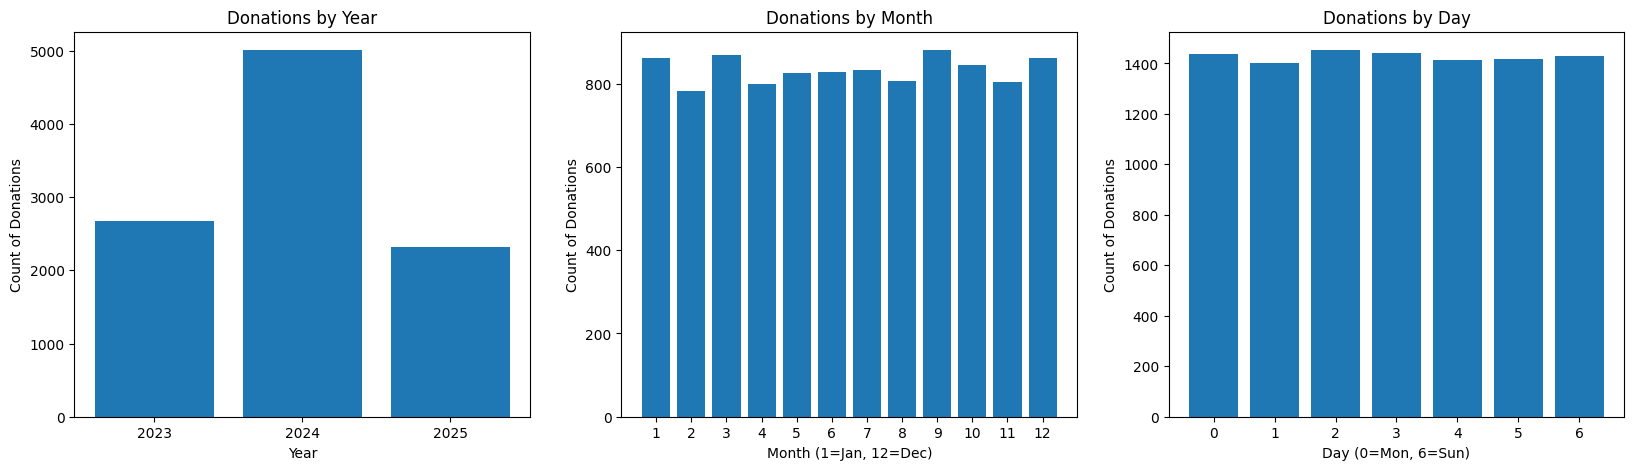

In [47]:
# Create a bar chart with matplotlib for a quick visual representation of when people donate

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

categorical_count_year = df_anonymised["donation_year"].value_counts().sort_index()
axes[0].bar(x=categorical_count_year.index, height=categorical_count_year)
axes[0].set_xticks(categorical_count_year.index)
axes[0].set_title("Donations by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count of Donations")

categorical_count_month = df_anonymised["donation_month"].value_counts().sort_index()
axes[1].bar(x=categorical_count_month.index, height=categorical_count_month)
axes[1].set_xticks(categorical_count_month.index)
axes[1].set_title("Donations by Month")
axes[1].set_xlabel("Month (1=Jan, 12=Dec)")
axes[1].set_ylabel("Count of Donations")

categorical_count_day = df_anonymised["donation_day"].value_counts().sort_index()
axes[2].bar(x=categorical_count_day.index, height=categorical_count_day)
axes[2].set_xticks(categorical_count_day.index)
axes[2].set_title("Donations by Day")
axes[2].set_xlabel("Day (0=Mon, 6=Sun)")
axes[2].set_ylabel("Count of Donations")

plt.show()

* *Troubleshooting Issues*: When I first loaded these graphs, one of the main issues I needed to address was Matplotlib auto-generating evenly-spaced ticks on the x-axis. 
My categorical year values, for instance, had been split on the x-axis as `2022.5`, `2023`, `2023.5` etc. 
In order to rectify this issue, I used generative AI to help me find the `.set_xticks()` function, as I could not find this covered in the LMS content for Matplotlib graphs.

---

---